
=== Symmetric coupling ===
runtime                 : 0.0524 s
number of time points   : 161
final TLS population    : 3.135445e-04
final N_out,L           : 4.998432e-01
final N_out,R           : 4.998432e-01
max |total - 1|         : 2.001066e-12
max |n_TLS - exp(-t)|   : 3.094083e-03

=== Right-chiral coupling ===
runtime                 : 0.0517 s
number of time points   : 161
final TLS population    : 3.135445e-04
final N_out,L           : 0.000000e+00
final N_out,R           : 9.996865e-01
max |total - 1|         : 2.000511e-12
max |n_TLS - exp(-t)|   : 3.094083e-03


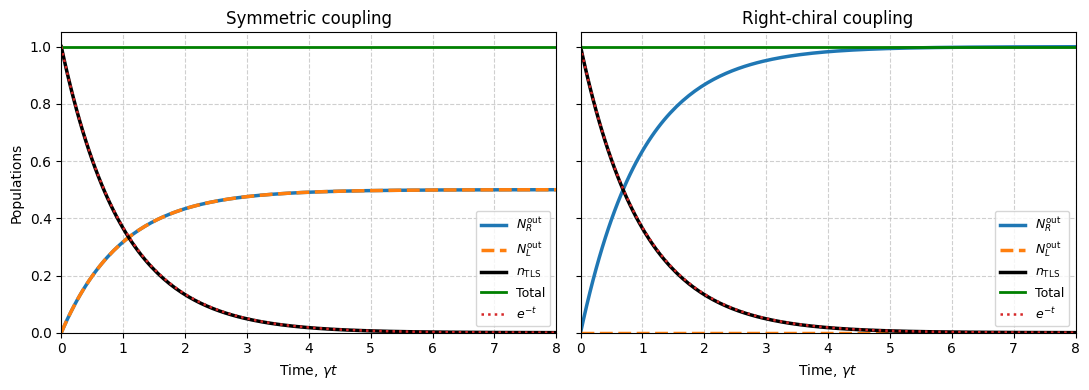

In [1]:
"""
1 TLS - Decay in infinite waveguide (seemps-style refactor)
================================================================

This is a cleaned and slightly more robust version of the first benchmark test:

1. Symmetric coupling into left/right channels
2. Right-chiral coupling

What this test checks
---------------------
- The simulation runs with the refactored wqedlib API.
- TLS population decays as expected.
- Output photon number accumulates in the correct channels.
- Total excitation number is approximately conserved.
- For the symmetric case, the TLS population is compared against exp(-gamma t).

Notes
-----
- Units are such that the total decay rate gamma = 1.
- The initial state is one TLS excitation and vacuum in the waveguide.
- This script is written to match the refactored package structure, but it keeps
  the original user-facing API style as much as possible.
"""

from __future__ import annotations

import time as _time
import numpy as np
import matplotlib.pyplot as plt

import wqedlib as qmps


# ============================================================
# Helpers
# ============================================================
def build_input_params(
    coupling_mode: str,
    gamma: float = 1.0,
    delta_t: float = 0.05,
    tmax: float = 8.0,
    bond_max: int = 18,
) -> qmps.InputParams:
    """Construct the standard single-TLS infinite-waveguide parameters."""
    d_t_total = np.array([2, 2], dtype=int)  # [left, right] local field dimensions
    d_sys_total = np.array([2], dtype=int)  # single TLS

    gamma_l, gamma_r = qmps.coupling(coupling_mode, gamma=gamma)

    return qmps.parameters.InputParams(
        delta_t=delta_t,
        tmax=tmax,
        d_sys_total=d_sys_total,
        d_t_total=d_t_total,
        gamma_l=gamma_l,
        gamma_r=gamma_r,
        bond_max=bond_max,
    )


def run_decay_case(params: qmps.InputParams):
    """Run one Markovian decay simulation and postprocess observables."""
    sys_initial_state = qmps.states.tls_excited()
    wg_initial_state = qmps.states.vacuum(params.tmax, params)
    hm = qmps.hamiltonian_1tls(params)

    start = _time.time()
    bins = qmps.t_evol_mar(hm, sys_initial_state, wg_initial_state, params)
    runtime = _time.time() - start

    tls_pop_op = qmps.tls_pop()
    b_pop_l = qmps.b_dag_l(params) @ qmps.b_l(params)
    b_pop_r = qmps.b_dag_r(params) @ qmps.b_r(params)

    tls_pop = np.real_if_close(
        qmps.single_time_expectation(bins.system_states, tls_pop_op)
    )
    photon_fluxes = np.real_if_close(
        qmps.single_time_expectation(bins.output_field_states, [b_pop_l, b_pop_r])
    )

    flux_l = np.asarray(photon_fluxes[0], dtype=float)
    flux_r = np.asarray(photon_fluxes[1], dtype=float)
    net_flux_l = np.cumsum(flux_l) * params.delta_t
    net_flux_r = np.cumsum(flux_r) * params.delta_t
    total_quanta = np.asarray(tls_pop, dtype=float) + net_flux_l + net_flux_r

    # Build the time axis from the returned data length.
    # This is safer than np.arange(0, tmax + dt, dt) if rounding ever changes.
    tlist = np.arange(len(tls_pop), dtype=float) * params.delta_t

    return {
        "params": params,
        "bins": bins,
        "tlist": tlist,
        "tls_pop": np.asarray(tls_pop, dtype=float),
        "flux_l": flux_l,
        "flux_r": flux_r,
        "net_flux_l": net_flux_l,
        "net_flux_r": net_flux_r,
        "total_quanta": total_quanta,
        "runtime": runtime,
    }


def print_summary(name: str, result: dict, gamma_total: float = 1.0) -> None:
    """Print a compact diagnostic summary."""
    tlist = result["tlist"]
    tls_pop = result["tls_pop"]
    total = result["total_quanta"]

    print(f"\n=== {name} ===")
    print(f"runtime                 : {result['runtime']:.4f} s")
    print(f"number of time points   : {len(tlist)}")
    print(f"final TLS population    : {tls_pop[-1]:.6e}")
    print(f"final N_out,L           : {result['net_flux_l'][-1]:.6e}")
    print(f"final N_out,R           : {result['net_flux_r'][-1]:.6e}")
    print(f"max |total - 1|         : {np.max(np.abs(total - 1.0)):.6e}")

    # Compare against the expected exponential decay for a single Markovian TLS.
    theo = np.exp(-gamma_total * tlist)
    err = np.max(np.abs(tls_pop - theo))
    print(f"max |n_TLS - exp(-t)|   : {err:.6e}")


# ============================================================
# Main benchmark
# ============================================================
def main() -> None:
    gamma_total = 1.0
    delta_t = 0.05
    tmax = 8.0
    bond_max = 4

    # -----------------------------
    # Case 1: symmetric coupling
    # -----------------------------
    params_sym = build_input_params(
        coupling_mode="symmetrical",
        gamma=gamma_total,
        delta_t=delta_t,
        tmax=tmax,
        bond_max=bond_max,
    )
    res_sym = run_decay_case(params_sym)
    print_summary("Symmetric coupling", res_sym, gamma_total=gamma_total)

    # -----------------------------
    # Case 2: right-chiral coupling
    # -----------------------------
    params_chr = build_input_params(
        coupling_mode="chiral_r",
        gamma=gamma_total,
        delta_t=delta_t,
        tmax=tmax,
        bond_max=bond_max,
    )
    res_chr = run_decay_case(params_chr)
    print_summary("Right-chiral coupling", res_chr, gamma_total=gamma_total)

    # ========================================================
    # Plotting
    # ========================================================
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

    # ----- symmetric -----
    ax = axes[0]
    tlist = res_sym["tlist"]
    theo = np.exp(-gamma_total * tlist)

    ax.plot(tlist, res_sym["net_flux_r"], lw=2.5, label=r"$N^{\rm out}_{R}$")
    ax.plot(tlist, res_sym["net_flux_l"], lw=2.5, ls="--", label=r"$N^{\rm out}_{L}$")
    ax.plot(tlist, res_sym["tls_pop"], lw=2.5, color="k", label=r"$n_{\rm TLS}$")
    ax.plot(tlist, res_sym["total_quanta"], lw=2.0, color="g", label="Total")
    ax.plot(tlist, theo, lw=1.8, ls=":", color="tab:red", label=r"$e^{-t}$")
    ax.set_title("Symmetric coupling")
    ax.set_xlabel(r"Time, $\gamma t$")
    ax.set_ylabel("Populations")
    ax.set_xlim(0.0, params_sym.tmax)
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=9)

    # ----- chiral -----
    ax = axes[1]
    tlist = res_chr["tlist"]
    theo = np.exp(-gamma_total * tlist)

    ax.plot(tlist, res_chr["net_flux_r"], lw=2.5, label=r"$N^{\rm out}_{R}$")
    ax.plot(tlist, res_chr["net_flux_l"], lw=2.5, ls="--", label=r"$N^{\rm out}_{L}$")
    ax.plot(tlist, res_chr["tls_pop"], lw=2.5, color="k", label=r"$n_{\rm TLS}$")
    ax.plot(tlist, res_chr["total_quanta"], lw=2.0, color="g", label="Total")
    ax.plot(tlist, theo, lw=1.8, ls=":", color="tab:red", label=r"$e^{-t}$")
    ax.set_title("Right-chiral coupling")
    ax.set_xlabel(r"Time, $\gamma t$")
    ax.set_xlim(0.0, params_chr.tmax)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


--- 0.08812165260314941 seconds ---


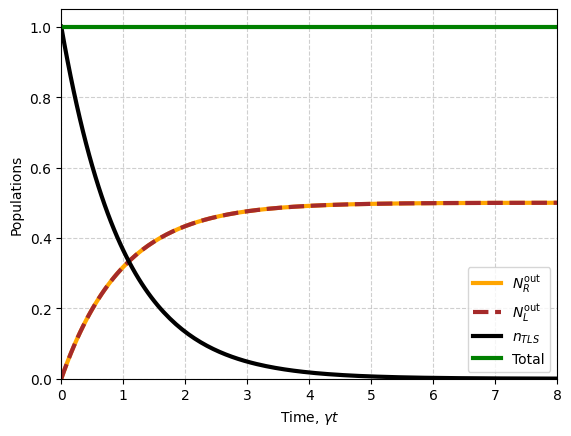

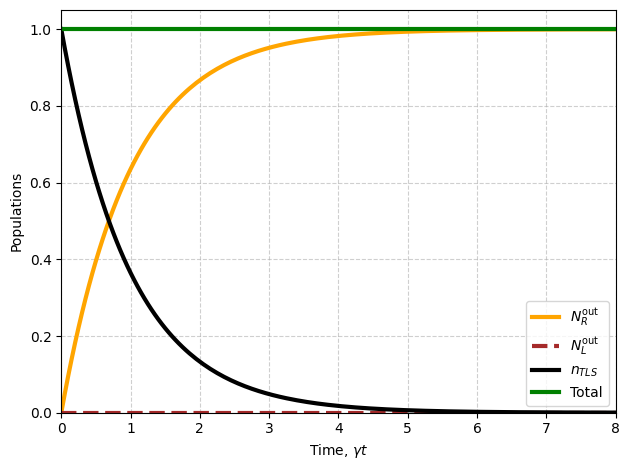

In [2]:
"""
1 TLS - Decay in infinite waveguide
===================================

This is a basic example of a single two-level system (TLS) decaying into an infinite waveguide. 

All the examples are in units of the TLS total decay rate, gamma. Hence, in general, gamma=1.

It covers two cases:
    
1. Symmetrical coupling into the waveguide

2. Chiral coupling, where the TLS is only coupled to the right channel of the waveguide.

"""


# %%
# Imports
# --------

import wqedlib as qmps
import matplotlib.pyplot as plt
import numpy as np
import time as t


# %%
# Symmetrical Solution
# ---------------------
#
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Choose the simulation parameters
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
#
# Setup of the bin size, coupling and input parameters:
#
#  * Size of each system bin (d_sys), this is the TLS Hilbert subspace, and the total system bin (d_sys_total) containing all the emitters.
#    For a single TLS, d_sys1=2 and d_sys_total=np.array([d_sys1]).
#
#  * Size of the time bins (d_t_total). This contains the field Hilbert subspace at each time step. In this case we allow one photon per time step and per right (d_t_r)
#    and left (d_t_l) channels. Hence, the subspace is d_t_total=np.array([d_t_l,d_t_r])
#
#  * Choice of coupling. Here, it is first calculated with symmetrical coupling, \gamma_l,gamma_r=qmps.coupling('symmetrical',gamma=1)
#    and then with chiral coupling, gamma_l,gamma_r=qmps.coupling('chiral_r',gamma=1)
#
#  * Input parameters (input_params). Define the data parameters that will be used in the calculation:
#
#     * Time step (delta_t)
#     * Maximum time (tmax)
#     * d_sys_total (as defined above)
#     * d_t_total (as defined above)
#     * Maximum bond dimension (bond). bond >=d_t_total(number of excitations).
#       Starting with the TLS excited and field in vacuum, 1 excitation enough with bond=4


# Choose the bins:
d_t_l = 2  # Time right channel bin dimension
d_t_r = 2  # Time left channel bin dimension
d_t_total = np.array([d_t_l, d_t_r])  # Total field bin dimensions

d_sys1 = 2  # tls bin dimension
d_sys_total = np.array([d_sys1])  # total system bin (in this case only 1 tls)

# Choose the coupling:
gamma_l, gamma_r = qmps.coupling(
    "symmetrical", gamma=1
)  # same as gamma_l, gamma_r = (0.5,0.5)

# Define input parameters (dataclass)
input_params = qmps.parameters.InputParams(
    delta_t=0.05,  # Time step of the simulation
    tmax=8,  # Maximum simulation time
    d_sys_total=d_sys_total,
    d_t_total=d_t_total,
    gamma_l=gamma_l,
    gamma_r=gamma_r,
    bond_max=4,  # Maximum bond dimension, simulation parameter that adjusts truncation of entanglement information
)

# Make a tlist for plots:
tmax = input_params.tmax
delta_t = input_params.delta_t
tlist = np.arange(0, tmax + delta_t, delta_t)

# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Choose the initial state and Hamiltonian
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# * Choice the system initial state. Here, initially excited.
#
# * Choice of the waveguide initial state. Here, starting in vacuum,
#  and considering that there is vacuum before the interaction until tmax.
#
# * Selection of the corresponding Hamiltonian.


""" Choose the initial state"""
sys_initial_state = qmps.states.tls_excited()  # TLS initially excited

# waveguide initially vacuum for as long as calculation (tmax)
wg_initial_state = qmps.states.vacuum(tmax, input_params)
# wg_initial_state = None # Another equivalent way to set the initial vacuum state

# To track computational time
start_time = t.time()

"""Choose the Hamiltonian"""
hm = qmps.hamiltonian_1tls(input_params)  # Create the Hamiltonian for a single TLS


# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Calculate the time evolution
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
#
# Time evolution calculation in the Markovian regime:

"""Calculate time evolution of the system"""
bins = qmps.t_evol_mar(hm, sys_initial_state, wg_initial_state, input_params)

# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Choose Relevant observables
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^
#
# * Get the TLS population with the tls_pop_op = qmps.tls_pop()
# * Get bosonic fluxes. This can be doe in two different ways:
#
#  * Using the boson operator:
#
#    b_pop_l = qmps.b_dag_l(input_params) @ qmps.b_l(input_params)
#
#    b_pop_r = qmps.b_dag_r(input_params) @ qmps.b_r(input_params)
#
#  * Using population operators directly:
#
#    b_pop_l = qmps.b_pop_l(input_params)
#
#    b_pop_r = qmps.b_pop_r(input_params)

"""Choose Observables"""
# Calculate the two level system population
tls_pop_op = qmps.tls_pop()

# Calculate the fluxes out of the TLS to the left and right
b_pop_l = qmps.b_dag_l(input_params) @ qmps.b_l(input_params)
b_pop_r = qmps.b_dag_r(input_params) @ qmps.b_r(input_params)

photon_pop_ops = [b_pop_l, b_pop_r]

# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^
# Calculate the observables
# ^^^^^^^^^^^^^^^^^^^^^^^^^^
#
# Get time dependent expectation values by acting on the relevant states (system/field) with
# your operators.
#
# Here, we calculate population dynamics, including the TLS population,
# photon fluxes, the integrated fluxes over time, and total quanta to
# check quanta conservation.

"""Calculate population dynamics"""
# Can calculate a single observable to get a time ordered ndarray of expectation values
# Use the system_states to calculate observables having to do with the emitter system
tls_pop = qmps.single_time_expectation(bins.system_states, tls_pop_op)

# Can also calculate a list of observables on the same states
# Use output_field_states to calculate observables of the outgoing field
photon_fluxes = qmps.single_time_expectation(bins.output_field_states, photon_pop_ops)

# Net photons propagating in each direction is the cumulatively integrated fluxes over time
net_flux_l = np.cumsum(photon_fluxes[0]) * delta_t
net_flux_r = np.cumsum(photon_fluxes[1]) * delta_t

# Add the integrated flux leaving the system with the TLS population for total quanta
total_quanta = tls_pop + net_flux_l + net_flux_r

print("--- %s seconds ---" % (t.time() - start_time))

# %%
# ^^^^^^^^^^^^^^^^
# Plot the results
# ^^^^^^^^^^^^^^^^
#
# Example plot containing,
# * Integrated photon flux traveling to the right
# * Integrated photon flux traveling to the left
# * TLS population
# * Conservation check (for one excitation it should be 1)


"""Plotting the results"""
plt.plot(
    tlist,
    np.real(net_flux_r),
    linewidth=3,
    color="orange",
    linestyle="-",
    label=r"$N^{\rm out}_{R}$",
)  # Photons propagating to the right channel
plt.plot(
    tlist,
    np.real(net_flux_l),
    linewidth=3,
    color="brown",
    linestyle="--",
    label=r"$N^{\rm out}_{L}$",
)  # Photons propagating to the left channel
plt.plot(
    tlist, np.real(tls_pop), linewidth=3, color="k", linestyle="-", label=r"$n_{TLS}$"
)  # TLS population
plt.plot(
    tlist, np.real(total_quanta), linewidth=3, color="g", linestyle="-", label="Total"
)  # Conservation check (for one excitation it should be 1)
plt.legend()
plt.xlabel(r"Time, $\gamma t$")
plt.ylabel("Populations")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, tmax])
plt.show()


# %%
# Right Chiral Solution
# ----------------------
#
# Similar example but now for a chiral TLS
# with an updated coupling to be coupled only to the right channel

# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Update the simulation coupling
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
gamma_l, gamma_r = qmps.coupling("chiral_r", gamma=1)

input_params.gamma_l = gamma_l
input_params.gamma_r = gamma_r

# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Update Hamiltonian with new coupling
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

hm = qmps.hamiltonian_1tls(input_params)

# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Calculate the time evolution
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^

"""Calculate time evolution of the system"""
bins = qmps.t_evol_mar(hm, sys_initial_state, wg_initial_state, input_params)

# %%
# ^^^^^^^^^^^^^^^^^^^^^^^^^^
# Calculate the observables
# ^^^^^^^^^^^^^^^^^^^^^^^^^^

"""Calculate population dynamics"""
tls_pop_ch = qmps.single_time_expectation(bins.system_states, tls_pop_op)
photon_fluxes_ch = qmps.single_time_expectation(
    bins.output_field_states, photon_pop_ops
)

net_fluxes = np.cumsum(photon_fluxes_ch, axis=1) * delta_t
total_quanta_ch = tls_pop_ch + np.sum(net_fluxes, axis=0)


# %%
# ^^^^^^^^^^^^^^^^
# Plot the results
# ^^^^^^^^^^^^^^^^

"""Plotting the results"""
plt.plot(
    tlist,
    np.real(net_fluxes[1]),
    linewidth=3,
    color="orange",
    linestyle="-",
    label=r"$N^{\rm out}_{R}$",
)  # Photons propagating to the right channel
plt.plot(
    tlist,
    np.real(net_fluxes[0]),
    linewidth=3,
    color="brown",
    linestyle="--",
    label=r"$N^{\rm out}_{L}$",
)  # Photons propagating to the left channel
plt.plot(
    tlist,
    np.real(tls_pop_ch),
    linewidth=3,
    color="k",
    linestyle="-",
    label=r"$n_{TLS}$",
)  # TLS population
plt.plot(
    tlist,
    np.real(total_quanta_ch),
    linewidth=3,
    color="g",
    linestyle="-",
    label="Total",
)  # Conservation check (for one excitation it should be 1)
plt.legend()
plt.xlabel(r"Time, $\gamma t$")
plt.ylabel("Populations")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, tmax])
plt.tight_layout()
plt.show()


In [4]:
np.diag(np.sqrt(np.arange(1, 4, dtype=float)), 1)

array([[0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.41421356, 0.        ],
       [0.        , 0.        , 0.        , 1.73205081],
       [0.        , 0.        , 0.        , 0.        ]])

times           = [0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14] ...
P_e(t)          = [1.         0.98013298 0.96066066 0.94157519 0.92286889 0.90453424
 0.88656384 0.86895045] ...
n_left(bin)     = [0.         0.00993351 0.00973616 0.00954273 0.00935315 0.00916733
 0.0089852  0.00880669] ...
n_right(bin)    = [0.         0.00993351 0.00973616 0.00954273 0.00935315 0.00916733
 0.0089852  0.00880669] ...
n_total(bin)    = [0.         0.01986702 0.01947232 0.01908547 0.01870629 0.01833466
 0.0179704  0.01761338] ...


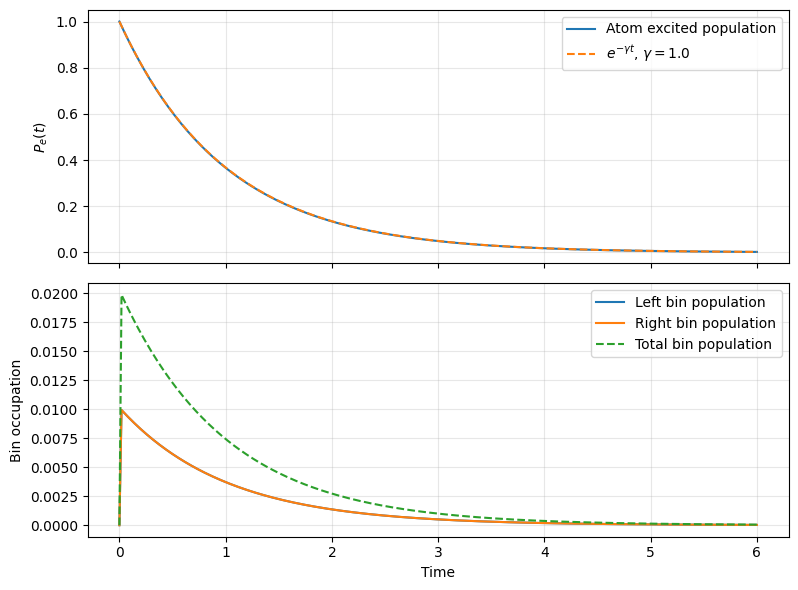

In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from seemps.state import CanonicalMPS, product_state, DEFAULT_STRATEGY
from seemps.expectation import expectation1
import wqedlib as qmps

# ============================================================
# Dataclasses
# ============================================================

Hamiltonian = np.ndarray | Callable[[int], np.ndarray]


@dataclass
class InputParams:
    delta_t: float
    tmax: float
    bond_max: int = 32
    d_sys_total: tuple[int, ...] = (2,)
    d_t_total: tuple[int, ...] = (2, 2)  # (left, right)
    gamma_L: float = 0.5
    gamma_R: float = 0.5
    delta: float = 0.0
    omega: float = 0.0
    atol: float = 1e-12


@dataclass
class BinsSeemps:
    psi_final: CanonicalMPS
    times: np.ndarray
    p_atom_excited: np.ndarray
    n_left_bins: np.ndarray
    n_right_bins: np.ndarray
    schmidt: list[np.ndarray]


# ============================================================
# Two-mode bin operators
#
# bin basis = |nL, nR>
#   0 -> |0,0>
#   1 -> |1,0>
#   2 -> |0,1>
#   3 -> |1,1>
#
# This is two qubits packed into one 4D local site.
# ============================================================

# ============================================================
# Local Hamiltonian for atom + one bidirectional time bin
# ============================================================


def atom_waveguide_markov_hamiltonian_lr(
    delta_t: float,
    gamma_L: float = 0.5,
    gamma_R: float = 0.5,
    delta: float = 0.0,
    omega: float = 0.0,
) -> np.ndarray:
    r"""
    One collision Hamiltonian for:
        atom (2D) + one time bin with left/right modes (4D)

    H = H_atom
        + i * sqrt(gamma_L/dt) * (aL^\dag sigma- - aL sigma+)
        + i * sqrt(gamma_R/dt) * (aR^\dag sigma- - aR sigma+)

    Returned shape: (2*4, 2*4) = (8, 8)
    """
    d_t_total = [2, 2]
    sm = qmps.sigma_minus()
    sp = qmps.sigma_plus()
    pe = qmps.proj_excited()
    aL = qmps.a_l(d_t_total)
    adagL = qmps.a_dag_l(d_t_total)
    aR = qmps.a_r(d_t_total)
    adagR = qmps.a_dag_r(d_t_total)
    Ibin = np.eye(4, dtype=complex)

    H_atom = delta * pe + 0.5 * omega * (sp + sm)

    H_int_L = np.sqrt(gamma_L / delta_t) * (np.kron(sm, adagL) + np.kron(sp, aL))
    H_int_R = np.sqrt(gamma_R / delta_t) * (np.kron(sm, adagR) + np.kron(sp, aR))

    H = np.kron(H_atom, Ibin) + H_int_L + H_int_R
    return H


def local_gate_from_hamiltonian(
    H: np.ndarray, delta_t: float, d_sys: int, d_t: int
) -> np.ndarray:
    """
    U[s'_sys, s'_bin, s_sys, s_bin]
    """
    U = expm(-1j * H * delta_t)
    return U.reshape(d_sys, d_t, d_sys, d_t)


def swap_gate(d1: int, d2: int) -> np.ndarray:
    """
    Rank-4 swap gate:
        S[j, i, i, j] = 1
    output indices first, input indices last
    """
    S = np.zeros((d2, d1, d1, d2), dtype=complex)
    for i in range(d1):
        for j in range(d2):
            S[j, i, i, j] = 1.0
    return S


# ============================================================
# MPS helpers
# ============================================================


def _try_replace_bond_limit(strategy, bond_max: int):
    for key in ("max_bond_dimension", "max_bond", "chi_max", "bond_max"):
        try:
            return strategy.replace(**{key: bond_max})
        except Exception:
            pass
    return strategy


def make_product_mps(
    i_s0_vec: np.ndarray,
    i_n0_vec: np.ndarray,
    n_steps: int,
) -> CanonicalMPS:
    """
    Chain order:
        [system, bin0, bin1, ..., bin_{n_steps-1}]
    """
    sites = [np.asarray(i_s0_vec, complex)]
    for _ in range(n_steps):
        sites.append(np.asarray(i_n0_vec, complex))

    psi0 = product_state(sites)
    return CanonicalMPS(psi0, center=0, normalize=True)


def merge_two_sites(psi: CanonicalMPS, site: int) -> np.ndarray:
    """
    AA[a, i, j, b]
    """
    A = psi[site]
    B = psi[site + 1]
    return np.tensordot(A, B, axes=(2, 0))


def apply_two_site_gate(AA: np.ndarray, U4: np.ndarray) -> np.ndarray:
    """
    U4[p, q, i, j], AA[a, i, j, b] -> AA'[a, p, q, b]
    """
    return np.einsum("pqij,aijb->apqb", U4, AA, optimize=True)


def schmidt_values_from_theta(
    AA: np.ndarray, bond_max: int | None = None
) -> np.ndarray:
    chiL, d1, d2, chiR = AA.shape
    M = AA.reshape(chiL * d1, d2 * chiR)
    s = np.linalg.svd(M, compute_uv=False)
    if bond_max is not None:
        s = s[:bond_max]
    return s


# ============================================================
# Main evolution
# ============================================================


def t_evol_mar_seemps_lr(
    ham: Hamiltonian,
    i_s0: np.ndarray,
    i_n0: np.ndarray,
    params: InputParams,
) -> BinsSeemps:
    """
    Markovian time-bin evolution with left/right bin modes packed
    into one 4D bin site.
    """
    delta_t = params.delta_t
    tmax = params.tmax
    d_t = int(np.prod(params.d_t_total))  # 2*2 = 4
    d_sys = int(np.prod(params.d_sys_total))  # 2
    n_steps = int(round(tmax / delta_t))

    if d_sys != len(i_s0):
        raise ValueError(f"d_sys={d_sys}, but len(i_s0)={len(i_s0)}")
    if d_t != len(i_n0):
        raise ValueError(f"d_t={d_t}, but len(i_n0)={len(i_n0)}")
    if d_sys != 2 or d_t != 4:
        raise NotImplementedError(
            "This version assumes atom qubit + 4D left/right bin."
        )

    psi = make_product_mps(i_s0, i_n0, n_steps)

    strategy = DEFAULT_STRATEGY.replace(tolerance=params.atol)
    strategy = _try_replace_bond_limit(strategy, params.bond_max)

    P_e = qmps.proj_excited()
    I = np.eye(2, dtype=complex)
    N_L = np.kron(qmps.tls_pop(), I)
    N_R = np.kron(I, qmps.tls_pop())
    SWAP4 = swap_gate(d_sys, d_t)

    times = np.arange(n_steps + 1) * delta_t
    p_atom_excited = np.zeros(n_steps + 1, dtype=float)
    n_left_bins = np.zeros(n_steps + 1, dtype=float)
    n_right_bins = np.zeros(n_steps + 1, dtype=float)
    schmidt_list: list[np.ndarray] = [np.array([1.0])]

    p_atom_excited[0] = float(np.real(expectation1(psi, P_e, 0)))

    for k in range(n_steps):
        atom_site = k
        bin_site = k + 1

        Hk = ham(k) if callable(ham) else ham
        U4 = local_gate_from_hamiltonian(Hk, delta_t, d_sys, d_t)

        # 1) local atom-bin evolution
        AA = merge_two_sites(psi, atom_site)
        AA = apply_two_site_gate(AA, U4)

        svals = schmidt_values_from_theta(AA, bond_max=params.bond_max)
        schmidt_list.append(svals)

        psi.update_2site_right(AA, atom_site, strategy)

        # 2) swap, move atom one site to the right
        AA = merge_two_sites(psi, atom_site)
        AA = apply_two_site_gate(AA, SWAP4)
        psi.update_2site_right(AA, atom_site, strategy)

        # after swap:
        #   site k   = output bin
        #   site k+1 = atom
        p_atom_excited[k + 1] = float(np.real(expectation1(psi, P_e, atom_site + 1)))
        n_left_bins[k + 1] = float(np.real(expectation1(psi, N_L, atom_site)))
        n_right_bins[k + 1] = float(np.real(expectation1(psi, N_R, atom_site)))

    return BinsSeemps(
        psi_final=psi,
        times=times,
        p_atom_excited=p_atom_excited,
        n_left_bins=n_left_bins,
        n_right_bins=n_right_bins,
        schmidt=schmidt_list,
    )


# ============================================================
# Plot
# ============================================================


def plot_dynamics(res: BinsSeemps, gamma_total: float | None = None):
    t = res.times
    pe = res.p_atom_excited
    nL = res.n_left_bins
    nR = res.n_right_bins

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # atom dynamics
    axes[0].plot(t, pe, label="Atom excited population")
    if gamma_total is not None:
        axes[0].plot(
            t,
            np.exp(-gamma_total * t),
            "--",
            label=rf"$e^{{-\gamma t}}$, $\gamma={gamma_total}$",
        )
    axes[0].set_ylabel(r"$P_e(t)$")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # emitted bin populations
    axes[1].plot(t, nL, label="Left bin population")
    axes[1].plot(t, nR, label="Right bin population")
    axes[1].plot(t, nL + nR, "--", label="Total bin population")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Bin occupation")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# Example
# ============================================================

if __name__ == "__main__":
    params = InputParams(
        delta_t=0.02,
        tmax=6.0,
        bond_max=16,
        gamma_L=0.5,
        gamma_R=0.5,
        delta=0.0,
        omega=0.0,
    )

    # atom initially excited
    # i_s0 = np.array([0.0, 1.0], dtype=complex)   # |e>
    i_s0 = qmps.tls_excited()

    # vacuum bin: |0L,0R> = |00>
    i_n0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)

    Hloc = atom_waveguide_markov_hamiltonian_lr(
        delta_t=params.delta_t,
        gamma_L=params.gamma_L,
        gamma_R=params.gamma_R,
        delta=params.delta,
        omega=params.omega,
    )

    res = t_evol_mar_seemps_lr(Hloc, i_s0, i_n0, params)

    gamma_total = params.gamma_L + params.gamma_R

    print("times           =", res.times[:8], "...")
    print("P_e(t)          =", res.p_atom_excited[:8], "...")
    print("n_left(bin)     =", res.n_left_bins[:8], "...")
    print("n_right(bin)    =", res.n_right_bins[:8], "...")
    print("n_total(bin)    =", (res.n_left_bins + res.n_right_bins)[:8], "...")

    plot_dynamics(res, gamma_total=gamma_total)